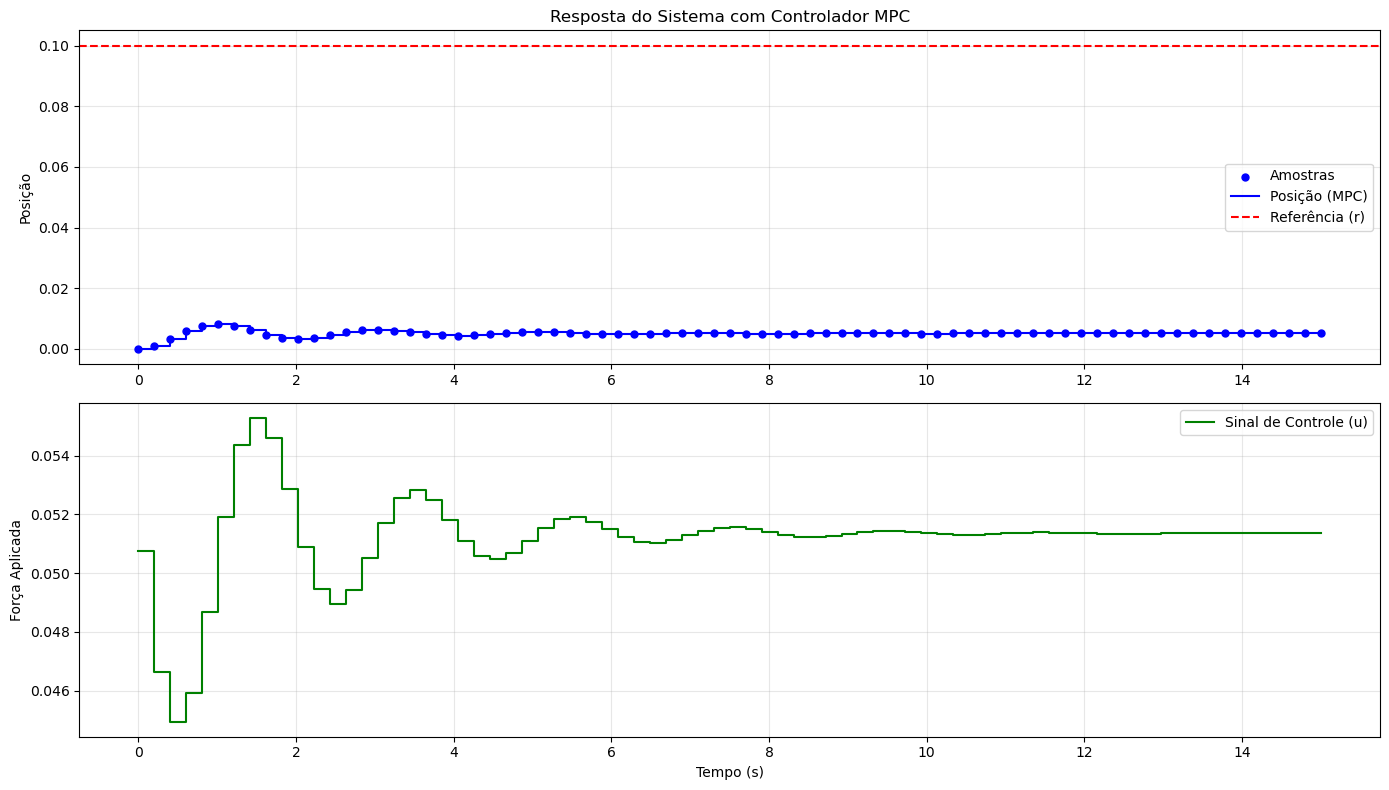

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cvxpy as cp

# ==========================================
# 1. Parâmetros da Planta
# ==========================================
m = 1.0
k = 10.0
b = 0.5

A = np.array([[0,       1],
              [-k/m, -b/m]])
B = np.array([[0],
              [1/m]])
C = np.eye(2) 
D = np.zeros((2, 1))

# ==========================================
# 2. Configurações da Simulação e MPC
# ==========================================
tf = 15.0
dt_disc = 0.2
passo = int(tf / dt_disc)
t_disc = np.linspace(0, tf, passo)

# Discretização (ZOH) exata como você fez
sys_continuo = signal.StateSpace(A, B, C, D)
sys_discreto = sys_continuo.to_discrete(dt_disc) 
Ad = sys_discreto.A
Bd = sys_discreto.B

# Parâmetros do Controlador MPC
N = 10               # Horizonte de predição (quantos passos no futuro o MPC enxerga)
lambda_weight = 0.1  # Penalidade no esforço de controle (lambda)
r = 0.1              # Referência desejada (equivalente a 1.0 / 10.0 do código antigo)

# ==========================================
# 3. Loop de Simulação em Malha Fechada
# ==========================================
x_history = np.zeros((passo, 2))
u_history = np.zeros(passo)

# Estado inicial da planta
x_atual = np.array([[0.0], [0.0]]) 

for i in range(passo):
    
    # --- Configuração do Problema de Otimização (CVXPY) ---
    # Y terá dimensão (2, N+1) para armazenar os estados desde o instante atual até N passos
    Y = cp.Variable((2, N + 1)) 
    # U terá dimensão (1, N) para armazenar as ações de controle futuras
    U = cp.Variable((1, N))     
    
    cost = 0
    constraints = []
    
    # Restrição 1: y[0] = estado atual da nossa planta real
    constraints += [Y[:, 0] == x_atual.flatten()]
    
    # Construção do horizonte de predição
    for j in range(N):
        # Minimização: (r - y)^2 + lambda * |u|^2
        # Y[0, j+1] é a posição predita. U[0, j] é a força aplicada.
        cost += cp.square(r - Y[0, j+1]) + lambda_weight * cp.square(U[0, j])
        
        # Restrição 2 (Dinâmica): Y[j+1] = Ad * Y[j] + Bd * U[j]
        constraints += [Y[:, j+1] == Ad @ Y[:, j] + Bd @ U[:, j]]
        
    # Declaração e resolução do problema
    prob = cp.Problem(cp.Minimize(cost), constraints)
    prob.solve(solver=cp.CLARABEL)
    
    # --- Aplicação do Controle (Horizonte Recedente) ---
    if U.value is None:
        print(f"Aviso: Solver falhou na iteração {i}. Aplicando força nula.")
        u_opt = 0.0
    else:
        # Pega APENAS a primeira ação de controle calculada da sequência ótima
        u_opt = U.value[0, 0] 
    
    # Salva os dados para o plot
    x_history[i] = x_atual.flatten()
    u_history[i] = u_opt
    
    # Simula a planta real avançando 1 passo de tempo com a ação escolhida
    x_atual = np.dot(Ad, x_atual) + Bd * u_opt


# ==========================================
# 4. Plotagem dos Resultados
# ==========================================
posicao_hist = x_history[:, 0]

plt.figure(figsize=(14, 8))

# Subplot 1: Posição do sistema (Escadinha vs Referência)
plt.subplot(2, 1, 1)
plt.scatter(t_disc, posicao_hist, color='blue', s=25, zorder=3, label='Amostras')
plt.step(t_disc, posicao_hist, where='post', color='blue', zorder=2, label='Posição (MPC)')
plt.axhline(y=r, color='red', linestyle='--', label='Referência (r)')
plt.ylabel('Posição')
plt.title('Resposta do Sistema com Controlador MPC')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Esforço de Controle
plt.subplot(2, 1, 2)
plt.step(t_disc, u_history, where='post', color='green', linewidth=1.5, label='Sinal de Controle (u)')
plt.xlabel('Tempo (s)')
plt.ylabel('Força Aplicada')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

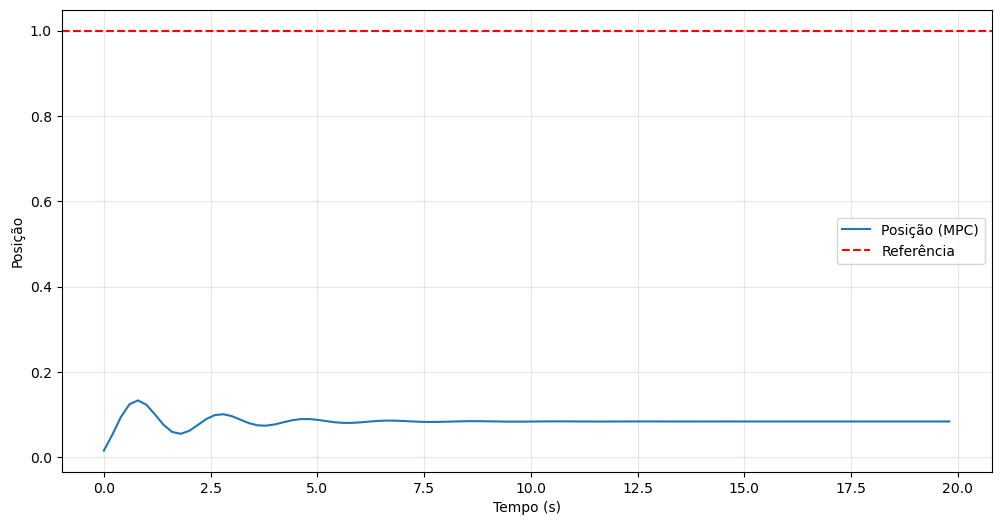

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cvxpy as cp

# ==========================================
# Parâmetros da planta
m = 1.0
k = 10.0
b = 0.5

A = np.array([[0,       1],
              [-k/m, -b/m]])
B = np.array([[0],
              [1/m]])
C = np.array([[1, 0]])   # só posição
D = np.array([[0]])

# ==========================================
# Discretização
dt = 0.2
sys_cont = signal.StateSpace(A, B, C, D)
sys_disc = sys_cont.to_discrete(dt)

Ad = sys_disc.A
Bd = sys_disc.B

# ==========================================
# Parâmetros do MPC
N = 20              # horizonte de predição
lambda_u = 0.1      # peso do esforço de controle
r = 1.0             # referência (posição desejada)

# ==========================================
def mpc_control(x0):

    # Variáveis de otimização
    x = cp.Variable((N, 1))        # entradas (controle)
    y = cp.Variable((N, 2))        # estados [posição, velocidade]

    cost = 0
    constraints = []

    # Condição inicial
    constraints += [y[0] == x0.flatten()]

    for i in range(N-1):
        # Dinâmica do sistema
        constraints += [y[i+1] == Ad @ y[i] + Bd @ x[i]]

        # Saída = posição
        pos = y[i][0]

        # Função custo
        cost += cp.square(r - pos) + lambda_u * cp.square(x[i])

    # Problema de otimização
    prob = cp.Problem(cp.Minimize(cost), constraints)

    prob.solve(solver=cp.CLARABEL)

    return x.value[0]  # aplica só o primeiro controle (MPC receding horizon)

# ==========================================
# Simulação com MPC
tf = 20
passos = int(tf / dt)

x_estado = np.array([[0.0], [0.0]])
historico_x = []
historico_u = []
tempo = []

for k_sim in range(passos):

    u = mpc_control(x_estado)

    # Atualiza planta
    x_estado = Ad @ x_estado + Bd * u

    historico_x.append(x_estado.flatten())
    historico_u.append(u)
    tempo.append(k_sim * dt)

historico_x = np.array(historico_x)

# ==========================================
# Plot
plt.figure(figsize=(12,6))

plt.plot(tempo, historico_x[:,0], label='Posição (MPC)')
plt.axhline(y=r, color='red', linestyle='--', label='Referência')

plt.xlabel('Tempo (s)')
plt.ylabel('Posição')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

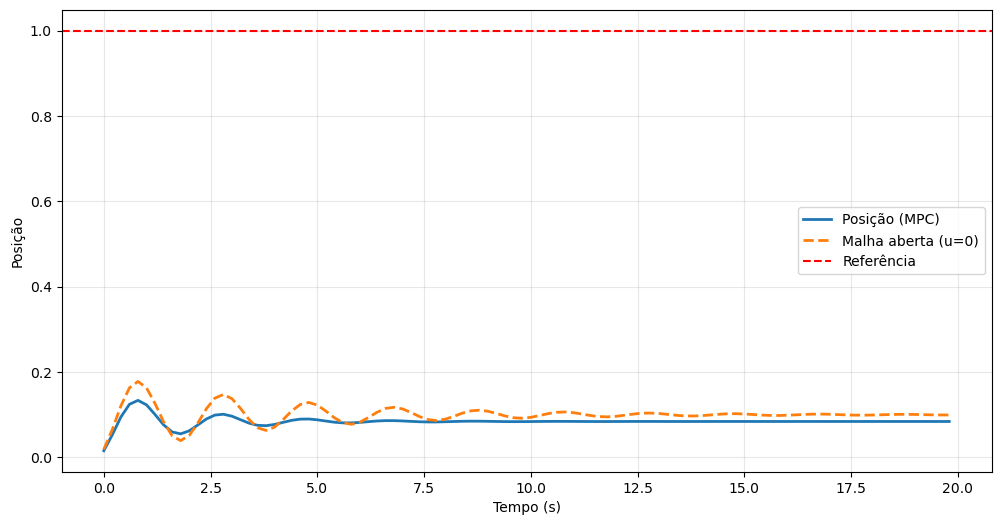

In [18]:
#simulaçao com MA
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cvxpy as cp

# ==========================================
# Parâmetros da planta
m = 1.0
k = 10.0
b = 0.5

A = np.array([[0,       1],
              [-k/m, -b/m]])
B = np.array([[0],
              [1/m]])
C = np.array([[1, 0]])   # só posição
D = np.array([[0]])

# ==========================================
# Discretização
dt = 0.2
sys_cont = signal.StateSpace(A, B, C, D)
sys_disc = sys_cont.to_discrete(dt)

Ad = sys_disc.A
Bd = sys_disc.B

# ==========================================
# Parâmetros do MPC
N = 20              # horizonte de predição
lambda_u = 0.1      # peso do esforço de controle
r = 1             # referência (posição desejada)

# ==========================================
def mpc_control(x0):

    # Variáveis de otimização
    x = cp.Variable((N, 1))        # entradas (controle)
    y = cp.Variable((N, 2))        # estados [posição, velocidade]

    cost = 0
    constraints = []

    # Condição inicial
    constraints += [y[0] == x0.flatten()]

    for i in range(N-1):
        # Dinâmica do sistema
        constraints += [y[i+1] == Ad @ y[i] + Bd @ x[i]]

        # Saída = posição
        pos = y[i][0]

        # Função custo
        cost += cp.square(r - pos) + lambda_u * cp.square(x[i])

    # Problema de otimização
    prob = cp.Problem(cp.Minimize(cost), constraints)

    prob.solve(solver=cp.CLARABEL)

    return x.value[0]  # aplica só o primeiro controle (MPC receding horizon)

# ==========================================
# Simulação com MPC
tf = 20
passos = int(tf / dt)

x_estado = np.array([[0.0], [0.0]])
historico_x = []
historico_u = []
tempo = []

for k_sim in range(passos):

    u = mpc_control(x_estado)

    # Atualiza planta
    x_estado = Ad @ x_estado + Bd * u

    historico_x.append(x_estado.flatten())
    historico_u.append(u)
    tempo.append(k_sim * dt)

historico_x = np.array(historico_x)

# ==========================================
# >>> MALHA ABERTA (ADICIONADO) <<<

x_open = np.array([[0.0], [0.0]])
historico_open = []

for k_sim in range(passos):

    u_open = 1.0  # sem controle

    x_open = Ad @ x_open + Bd * u_open
    historico_open.append(x_open.flatten())

historico_open = np.array(historico_open)

# ==========================================
# Plot
plt.figure(figsize=(12,6))

plt.plot(tempo, historico_x[:,0], label='Posição (MPC)', linewidth=2)
plt.plot(tempo, historico_open[:,0], '--', label='Malha aberta (u=0)', linewidth=2)

plt.axhline(y=r, color='red', linestyle='--', label='Referência')

plt.xlabel('Tempo (s)')
plt.ylabel('Posição')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

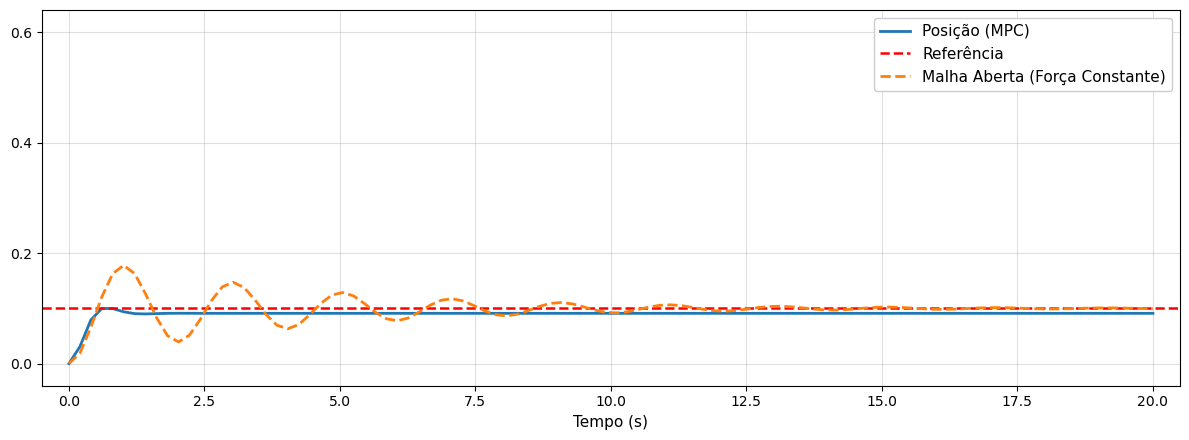

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import cvxpy as cp

# ==========================================
# 1. Parâmetros da Planta
# ==========================================
m = 1.0
k = 10.0
b = 0.5

A = np.array([[0,       1],
              [-k/m, -b/m]])
B = np.array([[0],
              [1/m]])
C = np.eye(2) 
D = np.zeros((2, 1))

# ==========================================
# 2. Configurações da Simulação e MPC
# ==========================================
tf = 20.0            # Alterado para 20.0 para o eixo X igualar à imagem
dt_disc = 0.2
passo = int(tf / dt_disc)
t_disc = np.linspace(0, tf, passo)

# Discretização (ZOH) exata como você fez
sys_continuo = signal.StateSpace(A, B, C, D)
sys_discreto = sys_continuo.to_discrete(dt_disc) 
Ad = sys_discreto.A
Bd = sys_discreto.B

# Parâmetros do Controlador MPC
N = 10               # Horizonte de predição (quantos passos no futuro o MPC enxerga)
lambda_weight = 0.001  # Penalidade no esforço de controle (lambda)
r = 0.1              # Referência desejada (equivalente a 1.0 / 10.0 do código antigo)

# ==========================================
# 3. Loop de Simulação em Malha Fechada
# ==========================================
x_history = np.zeros((passo, 2))
u_history = np.zeros(passo)

# Estado inicial da planta
x_atual = np.array([[0.0], [0.0]]) 

for i in range(passo):
    
    # --- Configuração do Problema de Otimização (CVXPY) ---
    # Y terá dimensão (2, N+1) para armazenar os estados desde o instante atual até N passos
    Y = cp.Variable((2, N + 1)) 
    # U terá dimensão (1, N) para armazenar as ações de controle futuras
    U = cp.Variable((1, N))     
    
    cost = 0
    constraints = []
    
    # Restrição 1: y[0] = estado atual da nossa planta real
    constraints += [Y[:, 0] == x_atual.flatten()]
    
    # Construção do horizonte de predição
    for j in range(N):
        # Minimização: (r - y)^2 + lambda * |u|^2
        cost += cp.square(r - Y[0, j+1]) + lambda_weight * cp.square(U[0, j])
        
        # Restrição 2 (Dinâmica): Y[j+1] = Ad * Y[j] + Bd * U[j]
        constraints += [Y[:, j+1] == Ad @ Y[:, j] + Bd @ U[:, j]]
        
    # Declaração e resolução do problema
    prob = cp.Problem(cp.Minimize(cost), constraints)
    prob.solve(solver=cp.CLARABEL)
    
    # --- Aplicação do Controle (Horizonte Recedente) ---
    if U.value is None:
        print(f"Aviso: Solver falhou na iteração {i}. Aplicando força nula.")
        u_opt = 0.0
    else:
        # Pega APENAS a primeira ação de controle calculada da sequência ótima
        u_opt = U.value[0, 0] 
    
    # Salva os dados para o plot
    x_history[i] = x_atual.flatten()
    u_history[i] = u_opt
    
    # Simula a planta real avançando 1 passo de tempo com a ação escolhida
    x_atual = np.dot(Ad, x_atual) + Bd * u_opt

# --- Simulação em Malha Aberta (Sem Controlador) ---
x_open_history = np.zeros((passo, 2))
x_open_atual = np.array([[0.0], [0.0]]) 
u_open = 1.0  # Força constante calculada para vencer a mola

for i in range(passo):
    x_open_history[i] = x_open_atual.flatten()
    # Avança a planta com a força constante
    x_open_atual = np.dot(Ad, x_open_atual) + Bd * u_open

posicao_open_hist = x_open_history[:, 0]
# ==========================================
# 4. Plotagem dos Resultados
# ==========================================
posicao_hist = x_history[:, 0]

# Cria uma figura com proporções semelhantes à da imagem fornecida
plt.figure(figsize=(12, 4.5))

# Plota a curva de posição e a referência
plt.plot(t_disc, posicao_hist, color='tab:blue', linewidth=2.0, label='Posição (MPC)')
plt.axhline(y=r, color='red', linestyle='--', linewidth=1.8, label='Referência')
plt.plot(t_disc, posicao_open_hist, '--', color='tab:orange', linewidth=2.0, label='Malha Aberta (Força Constante)')
# Configurações de eixos para replicar o visual desejado
plt.xlabel('Tempo (s)', fontsize=11)
plt.xlim(-0.5, tf + 0.5)         # Dá uma pequena margem antes do 0 e depois do 20
plt.ylim(-0.04, 0.64)            # Limites do eixo Y forçados para manter a escala da imagem
plt.yticks([0.0, 0.2, 0.4, 0.6]) # Valores exatos no eixo Y

# Adiciona legenda e grade
plt.legend(loc='upper right', fontsize=11, framealpha=1.0)
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()